# ITI5201 Machine Learning Assignment 2

#### Eddy, 33495068 

### Unsupervised Learning

In [30]:
#Importing the library for the code
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import tensor
from torch.optim import Adam
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

3.1 Load Task2C labeled.csv, Task2C unlabeled.csv, and Task2C test.csv datasets, along with the required libraries. Note that we will use both Task2C labeled.csv and Task2C unlabeled.csv to train the autoencoder, and only Task2C labeled.csv to train the classifiers. Finally, we will evaluate the trained classifier on the test dataset Task2C test.csv.

In [31]:
#Loading the labeled, unlabeled, and test data
labeled_data = pd.read_csv('Task2C_labeled.csv')
unlabeled_data = pd.read_csv('Task2C_unlabeled.csv')
test_data = pd.read_csv('Task2C_test.csv')

# Assuming the last column is the label and the first two columns are the features
x_labeled = np.array(labeled_data.iloc[:,1:])
y_labeled = np.array(labeled_data.iloc[:,0])
x_test = np.array(test_data.iloc[:,1:])
y_test = np.array(test_data.iloc[:,0])
unlabeled_data = np.array(unlabeled_data)



3.2 Train an autoencoder with only one hidden layer and change the number of its neurons to 20, 60, 100, ..., 220 (i.e. from 20 to 220 with a step size of 40).

In [32]:
#To normalize the data
def normalize(x, m=None, s=None): 
    if m is None or s is None:
        #print('Normalizing data: No mean and/or sd given. Assuming it is training data')
        m,s = x.mean(), x.std()
        
    return (x-m)/s

#Preparing the dataloader function to use for training. 
def get_dataloader(X_train,Y_train=None, autoencoder=False,bs=128, standardize=True, return_dataset=False):
   
    try:
        #Ensuring the data is np array and float type
        X_train= np.array(X_train).astype(np.float32)
        #Standardize the data if asked
        if standardize: X_train = normalize(X_train)
        if not autoencoder: Y_train = np.array(Y_train)
    except Exception as e:
        raise Exception('Make sure your input and labels are array-likes. Your input failed with exception: %s'%e)
    
    if autoencoder:
        Y_train = X_train
    
    #Transform the data into tensor
    X_train, Y_train = map(tensor, (X_train, Y_train))
    #Move the tensors into specified device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    X_train = X_train.to(device)
    Y_train = Y_train.to(device)
    
    #Create a TensorDataset and DataLoader
    train_ds = TensorDataset(X_train,Y_train)
    train_dl = DataLoader(train_ds, batch_size=16)
    
    if return_dataset: return train_dl,train_ds
    
    return train_dl

def train_autoencoder(X_train,hidden,activation='Tanh', seed=13, epochs=10, trace=True, **kwargs):
    #Setting the random seed
    np.random.seed(seed)
    torch.manual_seed(seed=seed)
    #Getting the dataloader
    train_dl = get_dataloader(X_train,autoencoder=True)
    
    #Setting the cpu as cuda if available
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    #Initialize the autoencoder structure
    n_inps = [X_train.shape[-1]] #Input size based on X train
    n_out = n_inps #Making sure the output size is the same as the input
    layer_dims = n_inps + hidden + n_out
    layers = []
    try:
        #Get the activation function from torch module
        non_linearity = getattr(nn,activation)()
    except AttributeError:
        raise Exception('Activation type not found, note that it is case senstive (ex: Tanh, Sigmoid,ReLU)')

    #Construct the layer of the autoencoder    
    for i in range(len(layer_dims)-1):
        layers.extend([nn.Linear(layer_dims[i], layer_dims[i+1]), non_linearity])
    
    layers.pop()  # to remove the last non-linearity

    model = nn.Sequential(*layers)
    model = model.to(device)
    # to capture training loss
    losses = []
    epoch_losses = []
    # define optimizer with learning rate
    optim = Adam(model.parameters(), **kwargs)
    # we use MSE error for reconstruction loss
    loss_criterion = nn.MSELoss()
    # calculate printing step - optional
    printing_step = int(epochs/10)
    # start training

    #Start the training loop
    for epoch in range(epochs):
        for xb,yb in train_dl:
            #Generate predictions for the current batch
            preds = model(xb)
            #Calculate the loss between prediction and the label
            loss = loss_criterion(preds,yb)
            losses.append(loss.item())
            #Backpropagate the loss to update the model weight
            loss.backward()
            optim.step()
            #Reseting the gradients to zero
            model.zero_grad()
        # after epoch
        epoch_loss = np.mean(losses[-len(train_dl):]) # average loss across all batches
        epoch_losses.append(epoch_loss)

    return model, epoch_losses


In [33]:
#Setting the activation function
activation = 'Tanh'
#Making the hidden neuron list
hidden = list(range(20, 221, 40))

#Initialize empty list to store the model and the losses
model = []
losses = []

#For loop to use the function with all the possible neuron
for x in hidden:
    a, b = train_autoencoder(    
        X_train = np.concatenate((x_labeled, unlabeled_data)), # training data
        hidden = [x], # number of layers and their units)
        seed = 13
    )
    #Append the model and the losses to the empty list
    model.append(a)
    losses.append(b)

3.3 For each model in Step II, calculate and record the reconstruction error for the autoencoder, which is simply the average of Euclidian distances between the input and output of the autoencoder. Plot these values where the x-axis is the number of units in the middle layer and the y-axis is the reconstruction error. Then, explain your findings based on the plot.

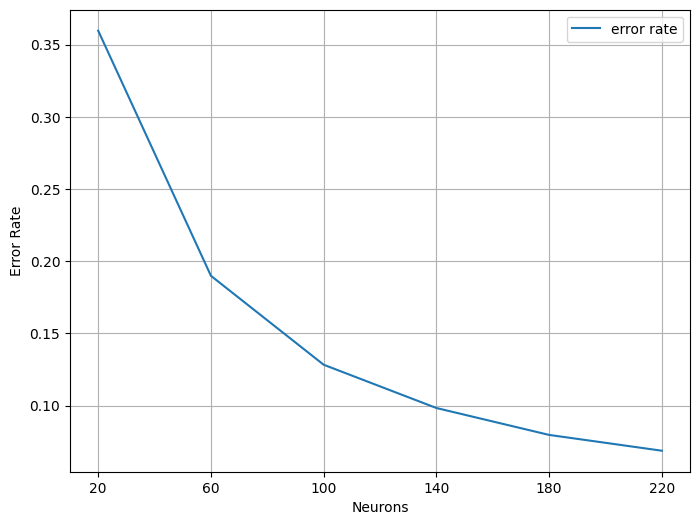

In [34]:
#Initialize the empty list
y_data = []

#Get the error rate from the losses
for h, i in enumerate(losses):
    y_data.append(i[-1])

#Initialize the plot
fig, axs = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(6)

#Plot the data into the graph
axs.plot(hidden, y_data, label='error rate')
#Set the x grid number
axs.set_xticks(np.array(hidden))
#write the x and y label
axs.set_xlabel('Neurons')
axs.set_ylabel('Error Rate')
axs.grid()
axs.legend()

3.4 Build the 3-layer NN to build a classification model using all the original attributes from the training set and change the number of its neurons to 20, 60, 100, ..., 220 (i.e. from 20 to 220 with a step size of 40). For each model, calculate and record the test error

In [35]:
#Import the classifier neural network and the loss fucntion
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import zero_one_loss

#Initialize empty list
error = []
#Using the MLP classifier to fit the labeled data and predict then predict it, After that save the error into the list
for l in hidden:
    #Fitthing the MLP classifier    
    nn_clf = MLPClassifier(hidden_layer_sizes=l, random_state=13, max_iter=500).fit(x_labeled, y_labeled)
    #Appending the zero one loss error
    error.append(zero_one_loss(nn_clf.predict(x_test),y_test))

3.5 Build augmented self-taught networks using the models learnt in Step II. For each model:
1) Add the output of the middle layer of an autoencoder as extra features to the original
feature set;

2) Train a new 3-layer Neural Network using all features (original + extra) and varying the
number of hidden neurons (like Step IV) as well.

3) Then calculate and record the test error.
For example, each model should be developed as follows: Model 1: 20 hidden neurons + extra
20 features (from an autoencoder), Model 2: 60 hidden neurons + extra 60 features (from an
autoencoder), ..., Model 5: 220 hidden neurons + extra 220 features (from an autoencoder).

In [36]:
def get_deepfeatures(trained_model, X_input,layer_number):
    '''
    Gets deep features of a given `layer_number` upon passing `X_input` through a `trained_model`   
    '''

    #Convert the input data into dataloader from the previous function
    X_input = get_dataloader(X_input,autoencoder=True,return_dataset=True)[1].tensors[0]
    #Initialize the empty list
    result = []
    #Save the result from the pass of the neural network
    def save_result(m,i,o):
        result.append(o.data)
    #Define the hook function to get the layer
    hook = trained_model[layer_number].register_forward_hook(save_result)
    #Perform the forward pass through the model without the gradient calculation
    with torch.no_grad():
        trained_model(X_input)

    hook.remove()
    #Return the saved layer
    return (result[0].cpu().numpy())

In [37]:
#Initialize the empty list
error_comb = []

#For loop to use the function with all possible neuron
for l in hidden:
    #Initialize the autoencoder
    enc_model, _ =train_autoencoder(    
        X_train = np.concatenate((x_labeled, unlabeled_data)), # training data
        hidden = [l], # number of layers and their units))
    )
    #Getting the extra features for x labeled from the auto encoder
    modified_train = get_deepfeatures(enc_model, x_labeled, layer_number=1)
    #Initializing the model with the x labeled and the extra feature
    nn_clf = MLPClassifier(hidden_layer_sizes=l, random_state=13, max_iter=500).fit(np.concatenate((modified_train,x_labeled), axis=1), y_labeled)
    #Getting the extra features for x test from the auto encoder
    modified_test = get_deepfeatures(enc_model, x_test, layer_number=1)
    #Saving the error rate of the NN + autoencoder
    error_comb.append(zero_one_loss(nn_clf.predict(np.concatenate((modified_test,x_test), axis=1)),y_test))


3.6 Plot the error rates for the 3-layer neural networks from Step IV and the augmented selftaught networks from Step V, while the x-axis is the number of hidden neurons and y-axis is the classification error. Explain how the performance of the 3-layer neural networks and the augmented self-taught networks is different and why they are different or why they are not different, based on the plot.

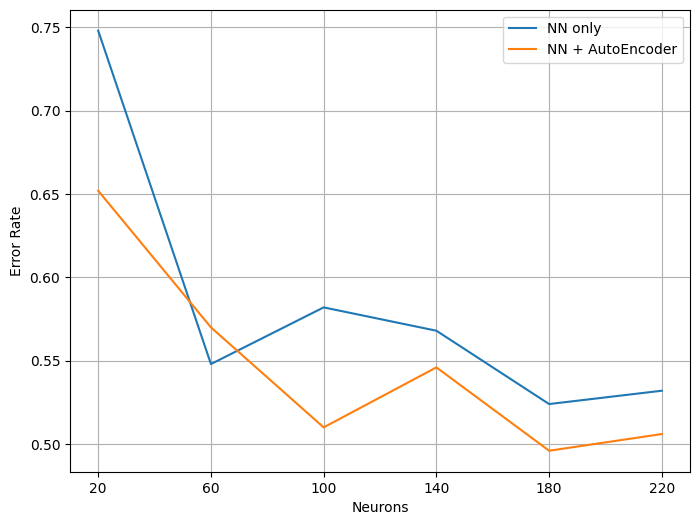

In [38]:
#Initialize the plot
fig, axs = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(6)

#Plot the data into the graph
axs.plot(hidden, error, label='NN only')
#Set the x grid number
axs.plot(hidden, error_comb, label='NN + AutoEncoder')
#write the x and y label
axs.set_xticks(np.array(hidden))
axs.set_xlabel('Neurons')
axs.set_ylabel('Error Rate')
axs.grid()
axs.legend()



Comparing the Augmented Self Taught Network (STN) with the normal 3 Neuron Neural Network (NN), we can see that generally, the STN perform better compared to the NN. This is caused by the STN being able to use the autoencoder to add more features to the model. Autoencoder enable the ability for the model to learn from unlabeled data by dimension reducing so that its able to generalize more to unlabeled data therefore it can perform better compared to normal Neural Network by leveraging unlabeled data for learning. This also helps makes the model became more robust to noise and variability which makes it more flexible too. Which is shown from the graph where STN perform better than traditional Neural Network. 